# Asian option variance reduction

Author: Fred J. Hickernell

This companion to the generating-samples notebook compares importance sampling, a European-call control variate, their combination, antithetic pairs, and randomized low discrepancy points for an arithmetic Asian-call price and a discretely monitored floating-strike lookback-call price.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/performance/AsianOptionVarianceReduction.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [2]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## Asian call and sampling map

Under the risk-neutral geometric Brownian model,
\begin{align*}
S(t)&=S_0\exp\{(r-\sigma^2/2)t+\sigma B(t)\},\\
f(\boldsymbol X)&=e^{-rT}\left(\frac1d\sum_{j=1}^d S(t_j)-K\right)_+.
\end{align*}

- **Target path:** $\boldsymbol X=(B(t_1),\ldots,B(t_d))\sim\operatorname{Norm}(\boldsymbol0,\mathsf\Sigma)$, with $\Sigma_{jk}=\min(t_j,t_k)$.
- **Output:** $Y=f(\boldsymbol X)$ is the discounted arithmetic Asian-call payoff; its mean $\mu=\mathbb E(Y)$ is the price.
- **Sampling map:** QMCPy's `BrownianMotion` supplies the uniform-to-path map developed in **Generating Samples**. Its Cholesky construction retains the chronological-increment interpretation.
- **Monitoring:** $t_j=jT/d$. The parameter cell uses `d=52` and `T=1` for weekly monitoring over one year. Changing `d` changes both the discretely monitored contract and the sampling dimension.
- **Variance reduction:** change the contribution while preserving its expectation.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp

%matplotlib inline

S0, K, r, sigma, T, d = 80.0, 100.0, 0.03, 0.7, 1.0, 52
# Change d to explore the monitoring frequency (52 gives weekly dates for T=1).
dt = T/d
times = dt*np.arange(1, d+1)
option_params = dict(start_price=S0, strike_price=K, interest_rate=r,
                     volatility=sigma, t_final=T, decomp_type="Cholesky")

def weighted_payoffs(w, theta=0.0, option="ASIAN", return_control=True):
    shifted_w = w + theta*times
    stock = S0*np.exp((r-sigma*sigma/2)*times + sigma*shifted_w)
    likelihood = np.exp(-theta*w[..., -1]-theta*theta*T/2)
    if option == "ASIAN":
        payoff = np.maximum(stock.mean(axis=-1)-K, 0)
    elif option == "LOOKBACK":
        minimum = np.minimum(S0, stock.min(axis=-1))
        payoff = stock[..., -1]-minimum
    else:
        raise ValueError('option must be "ASIAN" or "LOOKBACK".')
    target_payoff = np.exp(-r*T)*payoff*likelihood
    if not return_control:
        return target_payoff
    european = np.exp(-r*T)*np.maximum(stock[..., -1]-K, 0)*likelihood
    return np.stack([target_payoff, european])

# QMCPy transforms cube points to Brownian paths before evaluating the payoffs.
payoff_integrand = qp.CustomFun(
    qp.BrownianMotion(qp.IIDStdUniform(d), t_final=T, decomp_type="Cholesky"),
    g=weighted_payoffs, dimension_indv=(2,))

def payoffs(u, theta=0.0, option="ASIAN"):
    return payoff_integrand.f(u, theta=theta, option=option)

european_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="EUROPEAN", **option_params)
european_mean = european_option.get_exact_value()
print(f"Monitoring: {d} equally spaced dates over T={T:g} years")
print(f"Known European-call mean: {european_mean:.6f}")


Monitoring: 52 equally spaced dates over T=1 years
Known European-call mean: 16.578974


## Choose the low discrepancy generator

Set `LD_METHOD` to select a QMCPy construction:

- `"sobol"` (default): linearly scrambled and digitally shifted Sobol'.
- `"lattice"`: randomly shifted lattice.
- `"halton"`: randomized Halton.

After changing the selection, **rerun all cells**.

- The choice applies to the Asian-call comparison, lookback-call comparison, and price-tolerance stopping rule; labels follow the choice.
- Distinct replication seeds supply independent randomizations.
- Powers of two suit Sobol' and lattice constructions. Halton accepts other sample sizes, but the stopping rule still doubles its sample count at each step.


In [4]:
LD_METHOD = "sobol"  # Choose "sobol", "lattice", or "halton", then rerun all cells.

LD_LABELS = {"sobol": "Randomized Sobol'", "lattice": "Randomized lattice",
             "halton": "Randomized Halton"}
if LD_METHOD not in LD_LABELS:
    raise ValueError('LD_METHOD must be "sobol", "lattice", or "halton".')
LD_LABEL = LD_LABELS[LD_METHOD]


def ld_sampler(dimension, seed=None, replications=None):
    """Create a fresh QMCPy randomization with the selected construction."""
    if LD_METHOD == "sobol":
        return qp.DigitalNetB2(dimension, seed=seed, replications=replications,
                              randomize="LMS DS", order="RADICAL INVERSE")
    if LD_METHOD == "lattice":
        return qp.Lattice(dimension, seed=seed, replications=replications,
                          randomize="SHIFT", order="RADICAL INVERSE")
    # LMS DP supports the independent replications used by the stopping rule.
    return qp.Halton(dimension, seed=seed, replications=replications,
                     randomize="LMS DP")

print("Selected low discrepancy method:", LD_LABEL)


Selected low discrepancy method: Randomized Sobol'


## Importance sampling and a control variate

Choose the drifted proposal $\boldsymbol Z\sim\operatorname{Norm}(\boldsymbol a,\mathsf\Sigma)$, where $a_j=\theta t_j$. Its weight and alternative contribution are
\begin{align*}
w(\boldsymbol z)&=\exp\{-\theta z_d+\theta^2T/2\},\\
g_{\mathrm{IS}}(\boldsymbol z)&=f(\boldsymbol z)w(\boldsymbol z),\qquad
\mathbb E_{\mathrm{prop}}[g_{\mathrm{IS}}(\boldsymbol Z)]=\mu.
\end{align*}
- **Code coordinates:** construct $Z(t)=B(t)+\theta t$ from a zero-drift Brownian path. Thus $z_d=B(T)+\theta T$, and the same likelihood ratio is $\exp\{-\theta B(T)-\theta^2T/2\}$.
- **Control:** let $c(\boldsymbol x)$ be the European-call payoff and $\eta_1(\boldsymbol x)=c(\boldsymbol x)-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]$. Subtract $\beta\eta_1(\boldsymbol X)$ from $Y$.
- **Pilot:** choose $\beta$ with a **separate pilot sample**.
- **Under drift:** use the weighted European payoff minus its target mean as the zero-mean control; apply the same likelihood ratio to both payoffs.

Connect the construction to **Improving Efficiency**:

- Importance sampling uses the identity map with a nonconstant correction $w_T=w$.
- The inverse-normal/Brownian construction generates $\boldsymbol Z=\boldsymbol S_\theta(\boldsymbol U)$, with cube integrand $h_\theta=g_{\mathrm{IS}}\circ\boldsymbol S_\theta$.
- Zero drift gives an exact transport to the target: $w_T=1$ and $g_{\mathrm{ET}}=f\circ\boldsymbol S_0$.
- `payoffs(u, theta)` returns the composed, weighted contributions on uniform inputs.


In [5]:
pilot=qp.IIDStdUniform(d, seed=2026)(2**14)
def pilot_beta(theta, option="ASIAN", uniforms=None):
    a,c=payoffs(pilot if uniforms is None else uniforms,theta,option=option)
    return np.cov(a,c,ddof=1)[0,1]/np.var(c,ddof=1)

for theta in [0.0,1.0]:
    print(f"pilot beta for theta={theta:g}: {pilot_beta(theta):.4f}")

pilot beta for theta=0: 0.3627
pilot beta for theta=1: 0.3151


## Compare independent replications

For IID and the selected randomized low discrepancy sampler, compare four contributions:

- Plain payoff.
- Drift alone.
- Control alone.
- Drift plus control.

Keep the comparison consistent:

- **Sample size:** each estimate uses the same number of main samples.
- **Shared inputs:** within a sampler and replication, all four variants use the same uniform inputs.
- **Independent replications:** distinct seeds produce fresh IID samples or independent low discrepancy randomizations.
- **Fixed control:** fit each coefficient on a fresh independent pilot for each replication, then keep it fixed during that main run.
- **Variability:** report the empirical SD across replicated price estimates.

To experiment, change `theta_val` and rerun the next cell and its plot. Zero removes the drift. The stopping example has its own `theta_stopping` setting later.


**Cost for accuracy:** time each complete price estimate, including sampler construction, an independent pilot when needed, point generation, Brownian transforms, likelihood weights, and payoff evaluation. A plain run omits the European payoff. Shared model initialization, plotting, and diagnostic checks are outside the timer; drift tuning is not automated here.

- The table gives mean seconds per estimate and $s_R^2\bar t$, where $s_R$ is the across-replication SD and $\bar t$ the mean runtime. Smaller products suggest better variance per unit work when averaging independent runs of this fixed size.
- This is an empirical comparison on this machine, with sampling and timing uncertainty. It does not assume an IID rate for points within a randomized low discrepancy run or predict what happens when its sample size changes.
- Seeds match inputs across variants, but each method is timed as a stand-alone calculation; shared samples and pilots are regenerated and charged to each method.


In [6]:
n, repetitions=2**14,24
# Play with the importance-sampling drift here, then rerun this cell and its plot.
# theta_val=0 removes the drift; try other values and compare replication SD.
# This setting controls both IID and the selected low discrepancy drift variants.
theta_val = 1.5
methods=[("IID",0.0,False,"iid"),
         ("IID + drift",theta_val,False,"iid"),
         ("IID + control",0.0,True,"iid"),
         ("IID + both",theta_val,True,"iid"),
         (LD_LABEL,0.0,False,"ld"),
         (LD_LABEL + " + drift",theta_val,False,"ld"),
         (LD_LABEL + " + control",0.0,True,"ld"),
         (LD_LABEL + " + both",theta_val,True,"ld")]
def price_replication(option, theta, use_cv, design, seed, antithetic=False):
    started = time.perf_counter()
    beta = 0.0
    if use_cv:
        pilot_rows = qp.IIDStdUniform(d, seed=900000+seed)(len(pilot))
        beta = pilot_beta(theta, option=option, uniforms=pilot_rows)
    def contribution(w):
        output = weighted_payoffs(w, theta, option, return_control=use_cv)
        if use_cv:
            target, european = output
            return target-beta*(european-european_mean)
        return output
    integrand = qp.CustomFun(
        qp.BrownianMotion(qp.IIDStdUniform(d), t_final=T, decomp_type="Cholesky"),
        g=contribution)
    sampler = (ld_sampler(d, seed=seed) if design == "ld"
               else qp.IIDStdUniform(d, seed=seed))
    u = sampler(n//2 if antithetic else n)
    if antithetic:
        # n/2 independent pairs, n payoff evaluations in total.
        estimate = np.mean((integrand.f(u)+integrand.f(1-u))/2)
    else:
        estimate = np.mean(integrand.f(u))
    return estimate, time.perf_counter()-started


def compare_prices(option, first_seed):
    results, seconds = {}, {}
    for name, theta, use_cv, design in methods:
        runs = [price_replication(option, theta, use_cv, design, first_seed+rep)
                for rep in range(repetitions)]
        results[name], seconds[name] = np.asarray(runs).T
    return results, seconds


def price_table(results, seconds):
    from IPython.display import display, Markdown
    lines = ["| Method | Mean price | Replication SD | Seconds / estimate | SD squared × seconds |",
             "|:--|--:|--:|--:|--:|"]
    for name, values in results.items():
        sd, elapsed = values.std(ddof=1), seconds[name].mean()
        lines.append(f"| {name} | {values.mean():.5f} | {sd:.5f} | {elapsed:.4f} | {sd**2*elapsed:.5g} |")
    display(Markdown("\n".join(lines)))
    assert all(np.all(np.isfinite(v)) for v in results.values())

results, asian_seconds = compare_prices("ASIAN", 565)
price_table(results, asian_seconds)


| Method | Mean price | Replication SD | Seconds / estimate | SD squared × seconds |
|:--|--:|--:|--:|--:|
| IID | 7.16813 | 0.14123 | 0.0195 | 0.00038923 |
| IID + drift | 7.17773 | 0.07889 | 0.0191 | 0.00011857 |
| IID + control | 7.14701 | 0.08784 | 0.0392 | 0.00030285 |
| IID + both | 7.17052 | 0.07653 | 0.0386 | 0.00022584 |
| Randomized Sobol' | 7.16031 | 0.05170 | 0.0184 | 4.9092e-05 |
| Randomized Sobol' + drift | 7.17286 | 0.02762 | 0.0181 | 1.3841e-05 |
| Randomized Sobol' + control | 7.14769 | 0.03922 | 0.0380 | 5.8449e-05 |
| Randomized Sobol' + both | 7.16943 | 0.02738 | 0.0370 | 2.7713e-05 |

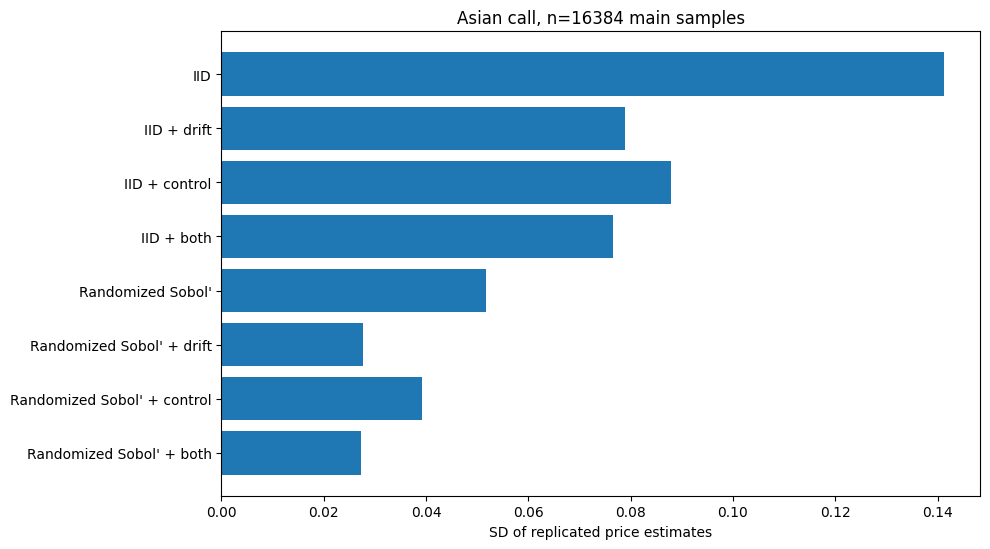

In [7]:
fig,ax=plt.subplots(figsize=(10,5.6))
names=list(results)
sd=[results[name].std(ddof=1) for name in names]
ax.barh(names,sd)
ax.invert_yaxis()
ax.set(xlabel="SD of replicated price estimates",title=f"Asian call, n={n} main samples")
fig.tight_layout()

- Drift, a control variate, and randomized low discrepancy sampling address different sources of error.
- Tune the drift and control coefficient with a pilot; the results shown concern this option and sample size.
- The timing includes the independent pilot for every controlled estimate; compare both SD and SD squared × seconds.


## A lookback call on the same paths

A floating-strike lookback call pays
\begin{align*}
S(T)-\min_{0\le j\le d}S(t_j),\qquad t_0=0.
\end{align*}

- **Monitoring:** the minimum includes the $d$ monitoring dates and the initial price. This is a discretely monitored option; continuous monitoring has a different value.
- **Strike:** this contract has no fixed strike $K$.
- **Paths:** retain the Asian example's Cholesky Brownian construction and asset-price map; replace the average-based payoff with the terminal price minus the monitored minimum.
- **Weights:** the drift likelihood ratio weights both the lookback payoff and the European-call control.
- **Control:** the European call retains its fixed strike $K$ and known mean.

Repeat all eight comparisons:

- Use plain, drift, control, and drift plus control for IID and the selected randomized low discrepancy sampler.
- Retain `n`, `repetitions`, and `theta_val` from the Asian example. Changing `LD_METHOD` and rerunning all cells switches Sobol', lattice, or Halton in both examples.
- Fit separate lookback control coefficients on each replication's independent pilot; keep each fixed during its main run.
- Share uniform inputs across the four variants within each sampler and replication.

The next cell checks the zero-drift payoff against QMCPy's `FinancialOption(option="LOOKBACK")`, including the initial price in the minimum. The table and plot report the SD across replicated price estimates. The table also reports stand-alone runtime and SD squared × seconds, including the pilot cost.


In [8]:
lookback_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="LOOKBACK", **option_params)
# Check the path-payoff implementation against QMCPy's discounted payoff.
lookback_check, _ = payoffs(pilot[:256], option="LOOKBACK")
np.testing.assert_allclose(lookback_check, lookback_option.f(pilot[:256]).reshape(-1),
                           rtol=1e-12, atol=1e-12)

lookback_results, lookback_seconds = compare_prices("LOOKBACK", 3320)
price_table(lookback_results, lookback_seconds)


| Method | Mean price | Replication SD | Seconds / estimate | SD squared × seconds |
|:--|--:|--:|--:|--:|
| IID | 33.86838 | 0.35739 | 0.0193 | 0.0024642 |
| IID + drift | 34.09415 | 0.11973 | 0.0192 | 0.00027502 |
| IID + control | 34.02312 | 0.09723 | 0.0391 | 0.00036983 |
| IID + both | 34.08993 | 0.11412 | 0.0389 | 0.00050677 |
| Randomized Sobol' | 34.06853 | 0.09614 | 0.0184 | 0.00017027 |
| Randomized Sobol' + drift | 34.06732 | 0.07720 | 0.0181 | 0.0001077 |
| Randomized Sobol' + control | 34.06846 | 0.07915 | 0.0377 | 0.00023628 |
| Randomized Sobol' + both | 34.07322 | 0.07850 | 0.0373 | 0.00022959 |

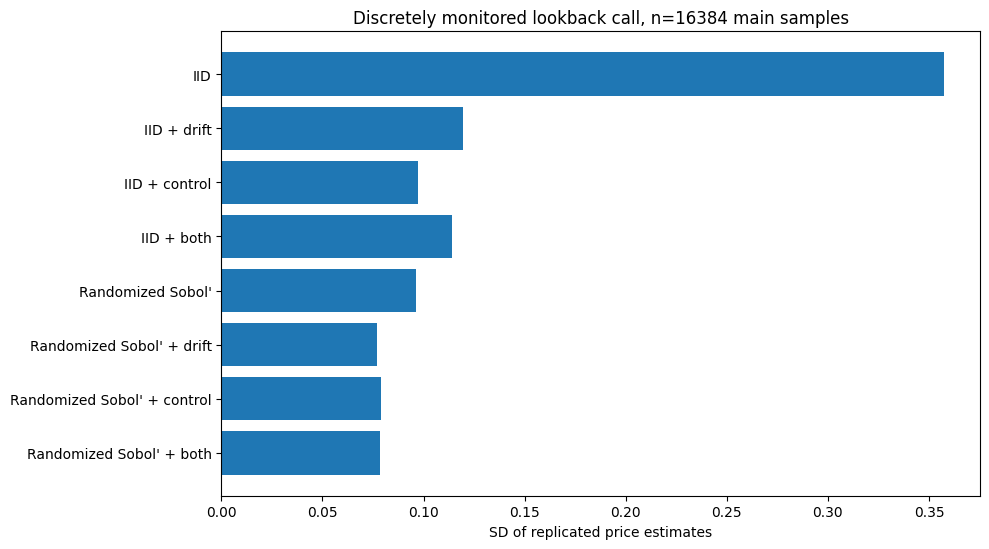

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.6))
names = list(lookback_results)
sd = [lookback_results[name].std(ddof=1) for name in names]
ax.barh(names, sd)
ax.invert_yaxis()
ax.set(xlabel="SD of replicated price estimates",
       title=f"Discretely monitored lookback call, n={n} main samples")
fig.tight_layout()


Compare the rankings with the arithmetic Asian-call plot:

- A drift chosen for the Asian payoff need not work well for the lookback payoff.
- The European control's correlation with the two payoffs differs; fit the lookback coefficients separately for each drift.
- Smaller replication SD means less observed sampling variability at this main-sample size. The timed comparison includes pilot work; a lower SD need not give the lowest cost for accuracy.

The stopping example below continues to price the **arithmetic Asian call**.


## Antithetic pairs at equal payoff cost

For the zero-drift cube integrand $h$, use $m=n/2$ independent IID inputs and pair each with its reflection:
\begin{align*}
Y_{\mathrm{Anti},i}&=\tfrac12\{h(\boldsymbol U_i)+h(\boldsymbol1-\boldsymbol U_i)\},\\
\widehat\mu_{\mathrm{Anti},n}&=\frac1m\sum_{i=0}^{m-1}Y_{\mathrm{Anti},i},\qquad n=2m.
\end{align*}

- **Equal evaluations:** compare $n$ plain payoffs with $m$ pairs, also requiring $n$ payoff evaluations. Pairing saves half the random inputs, but the timer measures the complete calculation.
- **Both contracts:** repeat for the arithmetic Asian and floating-strike lookback calls with the same monitoring model. There is no drift or control pilot in this comparison.
- **Error assessment:** compare SD across independent runs and SD squared × seconds. Negative within-pair correlation helps; pairing is not guaranteed to help an arbitrary payoff.
- **Combination:** antithetic pairing can also be applied to a modified cube integrand, but its benefit must be checked again. The eight-method comparisons above keep the roles of drift, controls, and low discrepancy points separate.

For the arithmetic Asian call, the payoff is increasing in each chronological Brownian increment. Reflection therefore gives nonpositive pair covariance and cannot increase the true variance at equal payoff count. An empirical SD from only 24 runs can still reverse that ranking; increase `repetitions` to investigate a small difference.


In [10]:
assert n % 2 == 0
for option, plain_results, plain_seconds, first_seed in [
        ("ASIAN", results, asian_seconds, 565),
        ("LOOKBACK", lookback_results, lookback_seconds, 3320)]:
    runs = np.asarray([price_replication(option, 0.0, False, "iid", first_seed+rep,
                                        antithetic=True)
                       for rep in range(repetitions)])
    print(f"{option}: {n:,} payoff evaluations per estimate")
    price_table({"IID": plain_results["IID"], "IID antithetic": runs[:, 0]},
                {"IID": plain_seconds["IID"], "IID antithetic": runs[:, 1]})


ASIAN: 16,384 payoff evaluations per estimate


| Method | Mean price | Replication SD | Seconds / estimate | SD squared × seconds |
|:--|--:|--:|--:|--:|
| IID | 7.16813 | 0.14123 | 0.0195 | 0.00038923 |
| IID antithetic | 7.18290 | 0.16156 | 0.0178 | 0.00046587 |

LOOKBACK: 16,384 payoff evaluations per estimate


| Method | Mean price | Replication SD | Seconds / estimate | SD squared × seconds |
|:--|--:|--:|--:|--:|
| IID | 33.86838 | 0.35739 | 0.0193 | 0.0024642 |
| IID antithetic | 33.99067 | 0.34264 | 0.0179 | 0.0020965 |

## Stop when the price uncertainty meets a tolerance

- **Contribution:** use the discounted Asian payoff and a European-call control fitted on the separate pilot; keep the coefficient fixed during the main run.
- **Uncertainty:** independent randomizations provide an approximate Student-$t$ interval for the average price.
- **Stop:** the reported half-width is at most $\varepsilon$ price units (`price_tolerance`), or the main-sample budget is exhausted.
- **Reference:** no exact Asian-option price is used.

For the drift $\theta$ chosen by `theta_stopping`, the cube contribution is
\begin{align*}
h_{\theta,\beta}(\boldsymbol u)
&=g_{\mathrm{IS}}(\boldsymbol S_\theta(\boldsymbol u))
-\beta\bigl[c(\boldsymbol S_\theta(\boldsymbol u))w(\boldsymbol S_\theta(\boldsymbol u))
-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]\bigr].
\end{align*}

Interpret the result:

- The control has mean zero, so the contribution still estimates the original price.
- Total work includes the pilot and all 32 main replications.
- The interval concerns **simulation error for the chosen $d$-date monitoring model**; it excludes model uncertainty, parameter uncertainty, and discrete-versus-continuous monitoring error.
- As in the [Keister stopping comparison](../applications/KeisterExample.ipynb#Practical-stopping-criteria), the interval is approximate. Nominal coverage does not automatically hold after adaptive stopping.


In [11]:
import warnings
from IPython.display import display, Markdown

print("Price stopping method:", LD_LABEL)
price_tolerance = 0.05  # Absolute price uncertainty target; try 0.01.
price_budget = 2**18  # Total main samples across all 32 randomizations.
# Play with the stopping example's drift here, independently of theta_val above.
# Rerun this cell: pilot_beta(theta_stopping) refits the control for that drift.
theta_stopping = 1.0
beta_stopping = pilot_beta(theta_stopping)

def controlled_cube_payoff(u):
    # QMCPy supplies (..., d), including a leading replication axis.
    asian, european = payoffs(u, theta_stopping)
    return asian-beta_stopping*(european-european_mean)

price_integrand = qp.CustomFun(
    qp.Uniform(ld_sampler(d, seed=5650, replications=32)),
    g=controlled_cube_payoff)
price_rule = qp.CubQMCRepStudentT(price_integrand, abs_tol=price_tolerance,
                                rel_tol=0, n_limit=price_budget, alpha=0.01)
with warnings.catch_warnings(record=True) as price_messages:
    warnings.simplefilter("always")
    price_solution, price_data = price_rule.integrate()
price_estimate = float(np.asarray(price_solution).item())
price_low = float(np.asarray(price_data.comb_bound_low).item())
price_high = float(np.asarray(price_data.comb_bound_high).item())
price_radius = max(price_estimate-price_low, price_high-price_estimate)
price_decision = "tolerance met" if price_radius <= price_tolerance else "not met"
pilot_count = len(pilot)
display(Markdown(
    f"| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |\n"
    f"|--:|--:|:--|--:|--:|--:|--:|:--|\n"
    f"| {price_tolerance:.2f} | {price_estimate:.5f} | [{price_low:.5f}, {price_high:.5f}] | "
    f"{price_radius:.5f} | {int(price_data.n_total):,} | {pilot_count:,} | "
    f"{int(price_data.n_total)+pilot_count:,} | {price_decision} |"))
for message in price_messages:
    print(f"{message.category.__name__}: {str(message.message).strip()}")
assert np.isfinite(price_estimate) and price_low <= price_estimate <= price_high
assert int(price_data.n_total) == 32*int(np.asarray(price_data.n_rep).item())


Price stopping method: Randomized Sobol'


| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |
|--:|--:|:--|--:|--:|--:|--:|:--|
| 0.05 | 7.16682 | [7.12989, 7.20376] | 0.03693 | 65,536 | 16,384 | 81,920 | tolerance met |

**Explore:**

- Request `price_tolerance = 0.01`, or reduce `price_budget`.
- Compare the reported decision and total work. A budget stop does not establish that the tolerance was met.
- Rerun with new pilot data to explore how the fitted coefficient and efficiency change; include the pilot in the work budget.


In [12]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 12.2 sec.
